# 岁月织机 (Loom of Time) — 深度学习训练
> **模型**：ResNet18 迁移学习（ImageNet 预训练）| **类别**：华南 / 陕西 / 云贵 / 江南 / 东北
> **策略**：前 5 epoch 只训练分类头，之后解冻全部层微调

In [1]:
import pathlib, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']  # macOS 中文字体
from PIL import Image
from tqdm.notebook import tqdm
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
warnings.filterwarnings('ignore')

# ── 路径 ──────────────────────────────────────────────────
DATASET_DIR  = pathlib.Path('data/spectrograms')          # dataset/{class}/{song}/clip_XXXX.png
CKPT_PATH    = pathlib.Path('models/loom_best.pth')

CLASSES      = ['huanan', 'shanxi', 'yungui', 'jiangnan', 'dongbei']
CLASS_ZH     = {'huanan':'华南', 'shanxi':'陕西', 'yungui':'云贵',
                 'jiangnan':'江南', 'dongbei':'东北'}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# ── 超参数 ────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
FREEZE_EPOCHS = 5        # 前 N epoch 冻结 backbone，只训练分类头
TOTAL_EPOCHS  = 30       # 总 epoch 数
LR_HEAD     = 3e-3       # 分类头学习率
LR_FINETUNE = 5e-5       # 解冻后全局学习率
VAL_SPLIT   = 0.2
PATIENCE    = 8          # 早停耐心值
SEED        = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = (torch.device('mps') if torch.backends.mps.is_available()
          else torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))

print(f'设备：{DEVICE}')
for c in CLASSES:
    n = sum(1 for _ in (DATASET_DIR/c).rglob('*.png'))
    print(f'  {CLASS_ZH[c]}({c}): {n} 张')

设备：mps
  华南(huanan): 369 张
  陕西(shanxi): 406 张
  云贵(yungui): 400 张
  江南(jiangnan): 427 张
  东北(dongbei): 411 张


## 2. Dataset（支持嵌套目录结构）

In [2]:
class FolkDataset(Dataset):
    """读取 dataset/{class}/{song}/clip_XXXX.png 结构"""
    def __init__(self, samples, transform=None):
        self.samples   = samples    # [(path, label), ...]
        self.transform = transform

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# 收集所有样本
all_samples = []
for cls in CLASSES:
    for png in (DATASET_DIR / cls).rglob('*.png'):
        all_samples.append((png, CLASS_TO_IDX[cls]))
random.shuffle(all_samples)

n_val   = max(1, int(len(all_samples) * VAL_SPLIT))
n_train = len(all_samples) - n_val
train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train:]

# 数据增强（训练集）
train_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),          # 频谱图水平翻转 = 时间逆序，合理
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = FolkDataset(train_samples, train_tf)
val_ds   = FolkDataset(val_samples,   val_tf)

# 加权采样：平衡各类别（防止类别不均衡影响训练）
label_counts = np.bincount([s[1] for s in train_samples], minlength=len(CLASSES))
weights      = 1.0 / (label_counts[np.array([s[1] for s in train_samples])] + 1e-6)
sampler      = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,    num_workers=0)

print(f'训练集：{len(train_ds)} 张 | 验证集：{len(val_ds)} 张')
print(f'各类别分布：{dict(zip(CLASSES, label_counts.tolist()))}')

训练集：1611 张 | 验证集：402 张
各类别分布：{'huanan': 292, 'shanxi': 330, 'yungui': 324, 'jiangnan': 336, 'dongbei': 329}


## 3. 频谱图样本预览

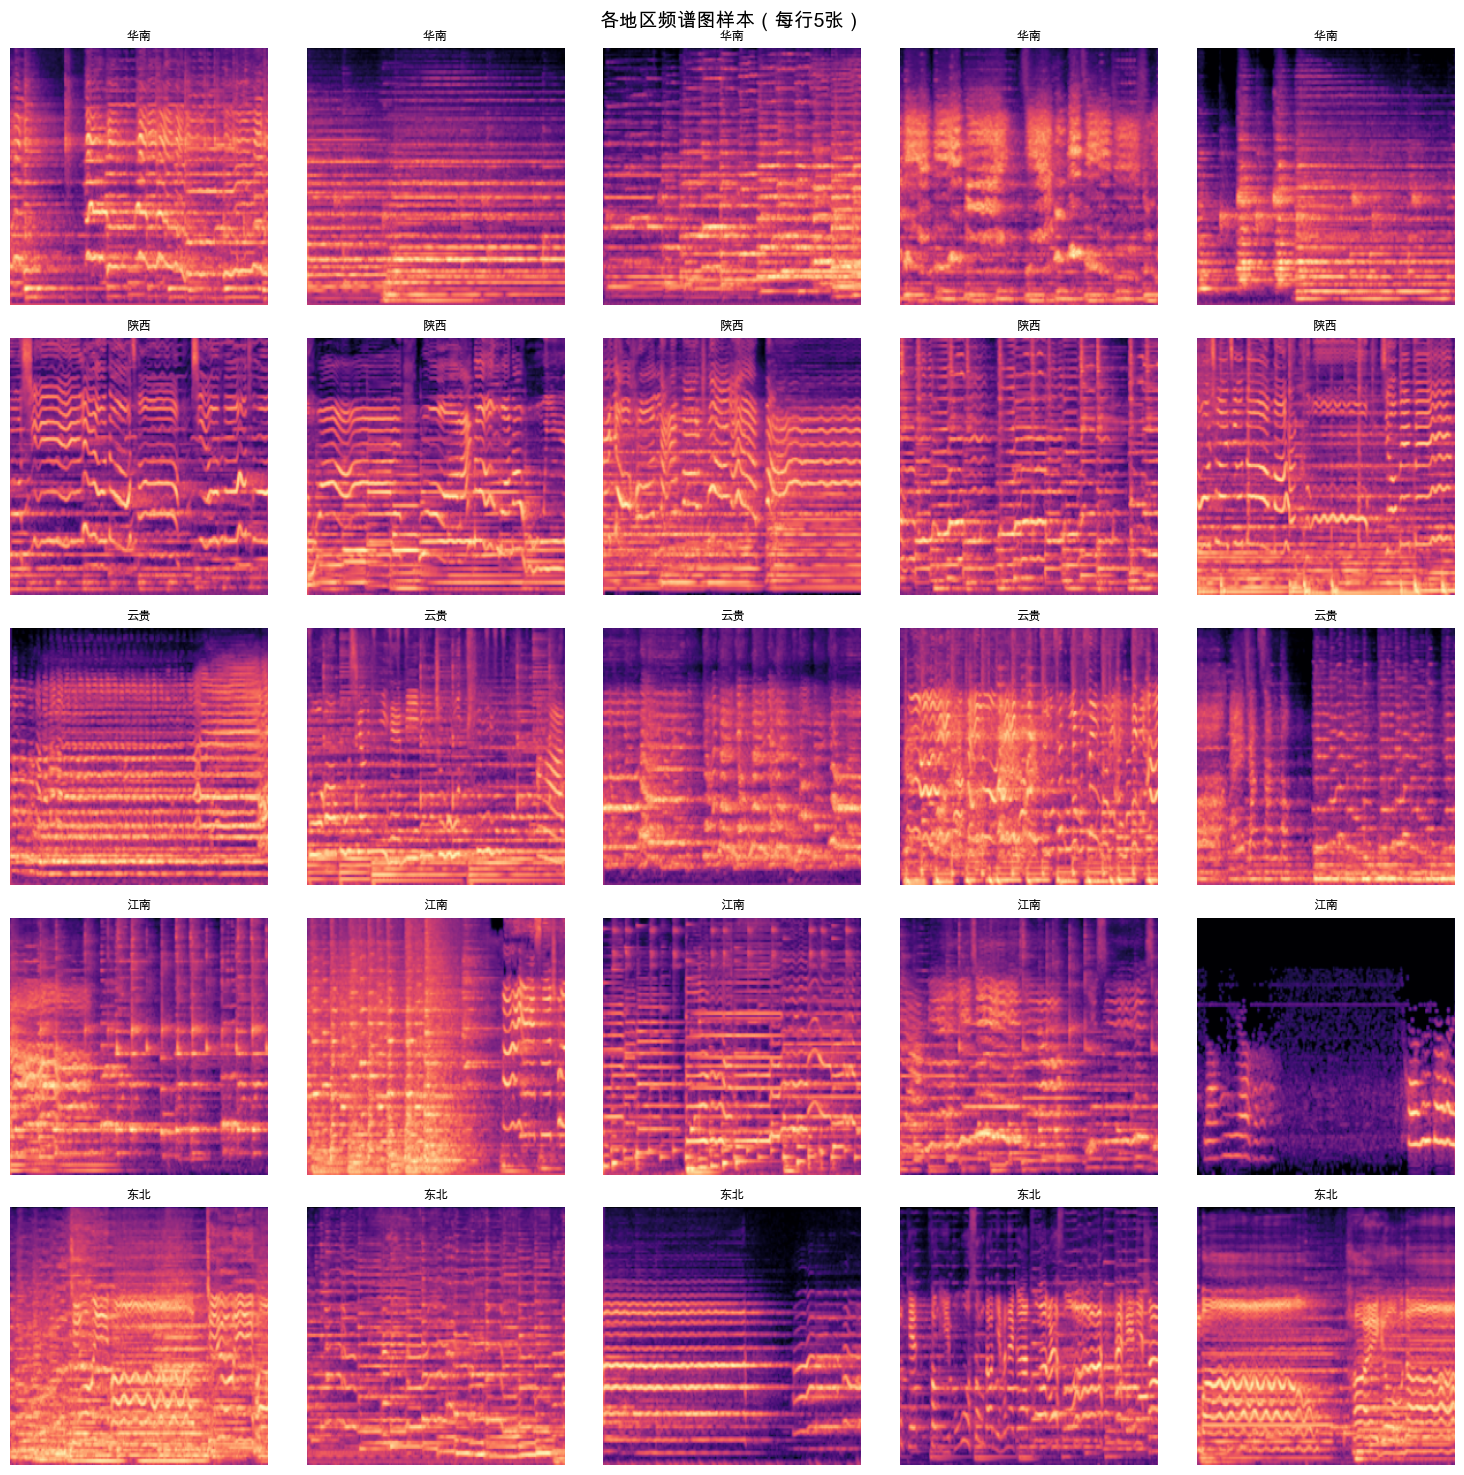

In [3]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, len(CLASSES)*3))
fig.suptitle('各地区频谱图样本（每行5张）', fontsize=14)
for row, cls in enumerate(CLASSES):
    imgs = list((DATASET_DIR/cls).rglob('*.png'))
    samples = random.sample(imgs, min(5, len(imgs)))
    for col in range(5):
        ax = axes[row][col]
        if col < len(samples):
            ax.imshow(Image.open(samples[col]))
            ax.set_title(f'{CLASS_ZH[cls]}', fontsize=9)
        ax.axis('off')
plt.tight_layout(); plt.show()

## 4. 模型：ResNet18 迁移学习

In [4]:
def build_model(num_classes=5, freeze_backbone=True):
    """
    ResNet18 预训练权重 + 替换最后全连接层为 5 分类头。
    freeze_backbone=True：只训练分类头（前几个 epoch 用）
    freeze_backbone=False：全部参数参与训练（微调阶段）
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

    # 替换分类头：加一层 Dropout 防止过拟合
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

model = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'总参数：{total:,}  |  可训练（分类头）：{trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/ruanhaoyu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:30<00:00, 1.53MB/s]


总参数：11,309,125  |  可训练（分类头）：132,613


## 5. 训练（两阶段 + 早停 + 实时曲线）

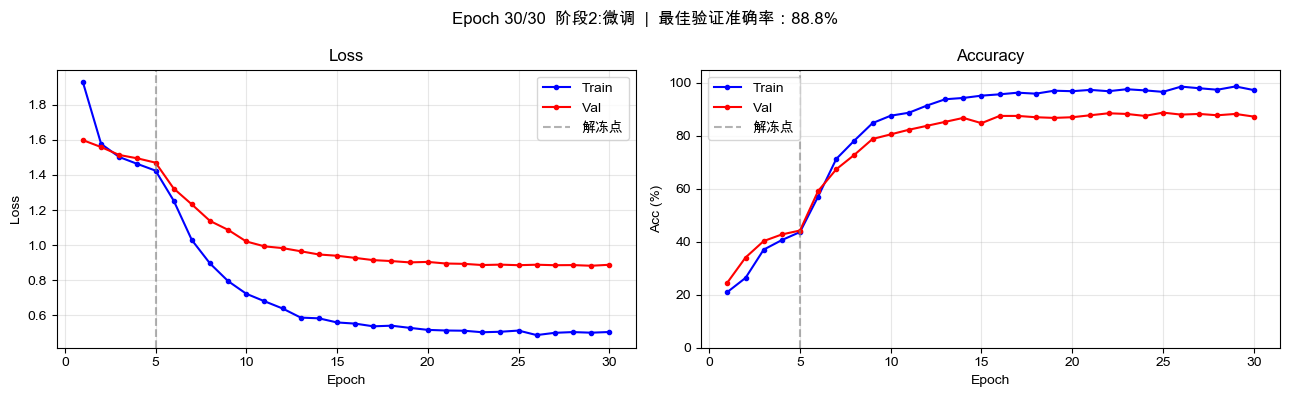

Epoch  30/30  Train 0.5046/97.3%  Val 0.8878/87.3%  LR=0.0e+00

训练完成！最佳验证准确率：88.81%


In [5]:
from IPython.display import clear_output

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing 缓解过拟合
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=LR_HEAD, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc   = 0.0
patience_count = 0

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct    += logits.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

def plot_history(epoch):
    clear_output(wait=True)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, len(history['train_loss'])+1)
    a1.plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
    a1.plot(ep, history['val_loss'],   'r-o', ms=3, label='Val')
    if FREEZE_EPOCHS < len(ep):
        a1.axvline(FREEZE_EPOCHS, color='gray', ls='--', alpha=0.6, label='解冻点')
    a1.set(title='Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, [x*100 for x in history['train_acc']], 'b-o', ms=3, label='Train')
    a2.plot(ep, [x*100 for x in history['val_acc']],   'r-o', ms=3, label='Val')
    if FREEZE_EPOCHS < len(ep):
        a2.axvline(FREEZE_EPOCHS, color='gray', ls='--', alpha=0.6, label='解冻点')
    a2.set(title='Accuracy', xlabel='Epoch', ylabel='Acc (%)', ylim=(0,105))
    a2.legend(); a2.grid(alpha=0.3)
    phase = '阶段1:热身' if epoch <= FREEZE_EPOCHS else '阶段2:微调'
    plt.suptitle(f'Epoch {epoch}/{TOTAL_EPOCHS}  {phase}  |  最佳验证准确率：{best_val_acc*100:.1f}%', fontsize=12)
    plt.tight_layout(); plt.show()

print('开始训练...')
for epoch in range(1, TOTAL_EPOCHS + 1):

    # ── 阶段切换：第 FREEZE_EPOCHS+1 epoch 解冻全部层 ──────
    if epoch == FREEZE_EPOCHS + 1:
        print('\n>>> 解冻全部层，切换为微调模式...')
        for p in model.parameters(): p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=TOTAL_EPOCHS - FREEZE_EPOCHS)

    tr_loss, tr_acc = run_epoch(train_loader, True)
    vl_loss, vl_acc = run_epoch(val_loader,   False)
    scheduler.step()

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc'],
                    [tr_loss, vl_loss, tr_acc, vl_acc]):
        history[k].append(v)

    plot_history(epoch)
    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{TOTAL_EPOCHS}  '
          f'Train {tr_loss:.4f}/{tr_acc*100:.1f}%  '
          f'Val {vl_loss:.4f}/{vl_acc*100:.1f}%  LR={lr_now:.1e}')

    # ── 保存最优权重 ────────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), str(CKPT_PATH))
        print(f'  ✓ 新最优：{vl_acc*100:.2f}%  已保存 → {CKPT_PATH}')
    else:
        patience_count += 1
        if patience_count >= PATIENCE and epoch > FREEZE_EPOCHS:
            print(f'\n早停触发（{PATIENCE} epoch 无提升），停止训练')
            break

print(f'\n训练完成！最佳验证准确率：{best_val_acc*100:.2f}%')

## 6. 混淆矩阵 & 分类报告

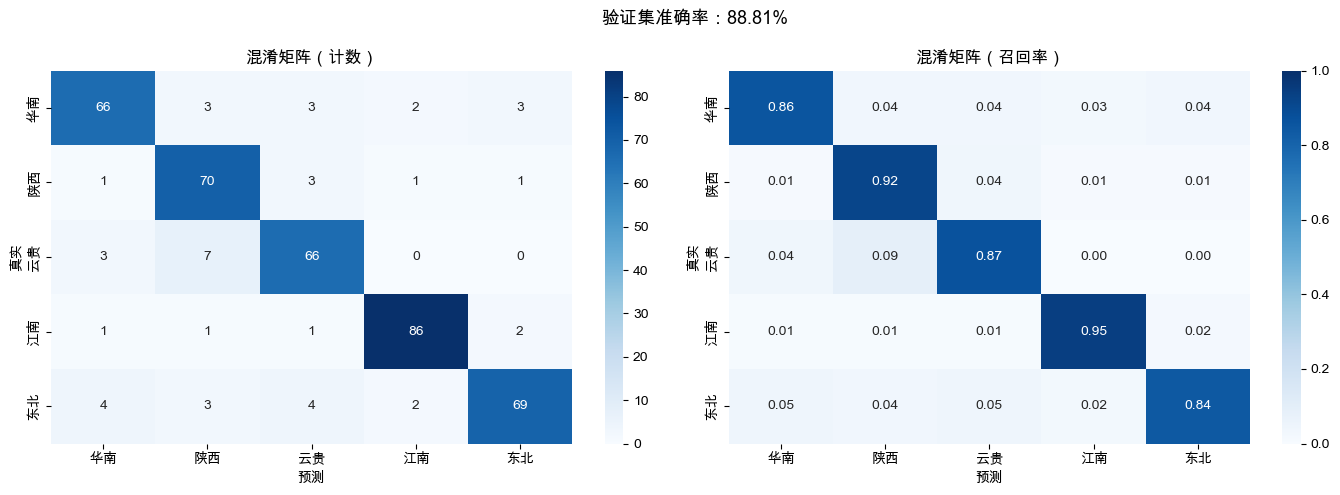

              precision    recall  f1-score   support

          华南       0.88      0.86      0.87        77
          陕西       0.83      0.92      0.88        76
          云贵       0.86      0.87      0.86        76
          江南       0.95      0.95      0.95        91
          东北       0.92      0.84      0.88        82

    accuracy                           0.89       402
   macro avg       0.89      0.89      0.89       402
weighted avg       0.89      0.89      0.89       402



In [6]:
model.load_state_dict(torch.load(str(CKPT_PATH), map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        all_preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

labels_zh = [CLASS_ZH[c] for c in CLASSES]
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,      annot=True, fmt='d',   cmap='Blues',
            xticklabels=labels_zh, yticklabels=labels_zh, ax=ax1)
ax1.set(title='混淆矩阵（计数）', xlabel='预测', ylabel='真实')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=labels_zh, yticklabels=labels_zh, ax=ax2)
ax2.set(title='混淆矩阵（召回率）', xlabel='预测', ylabel='真实')
plt.suptitle(f'验证集准确率：{best_val_acc*100:.2f}%', fontsize=13)
plt.tight_layout(); plt.show()
print(classification_report(all_labels, all_preds,
      target_names=labels_zh, zero_division=0))

## 7. 特征图可视化（ResNet 第一层）

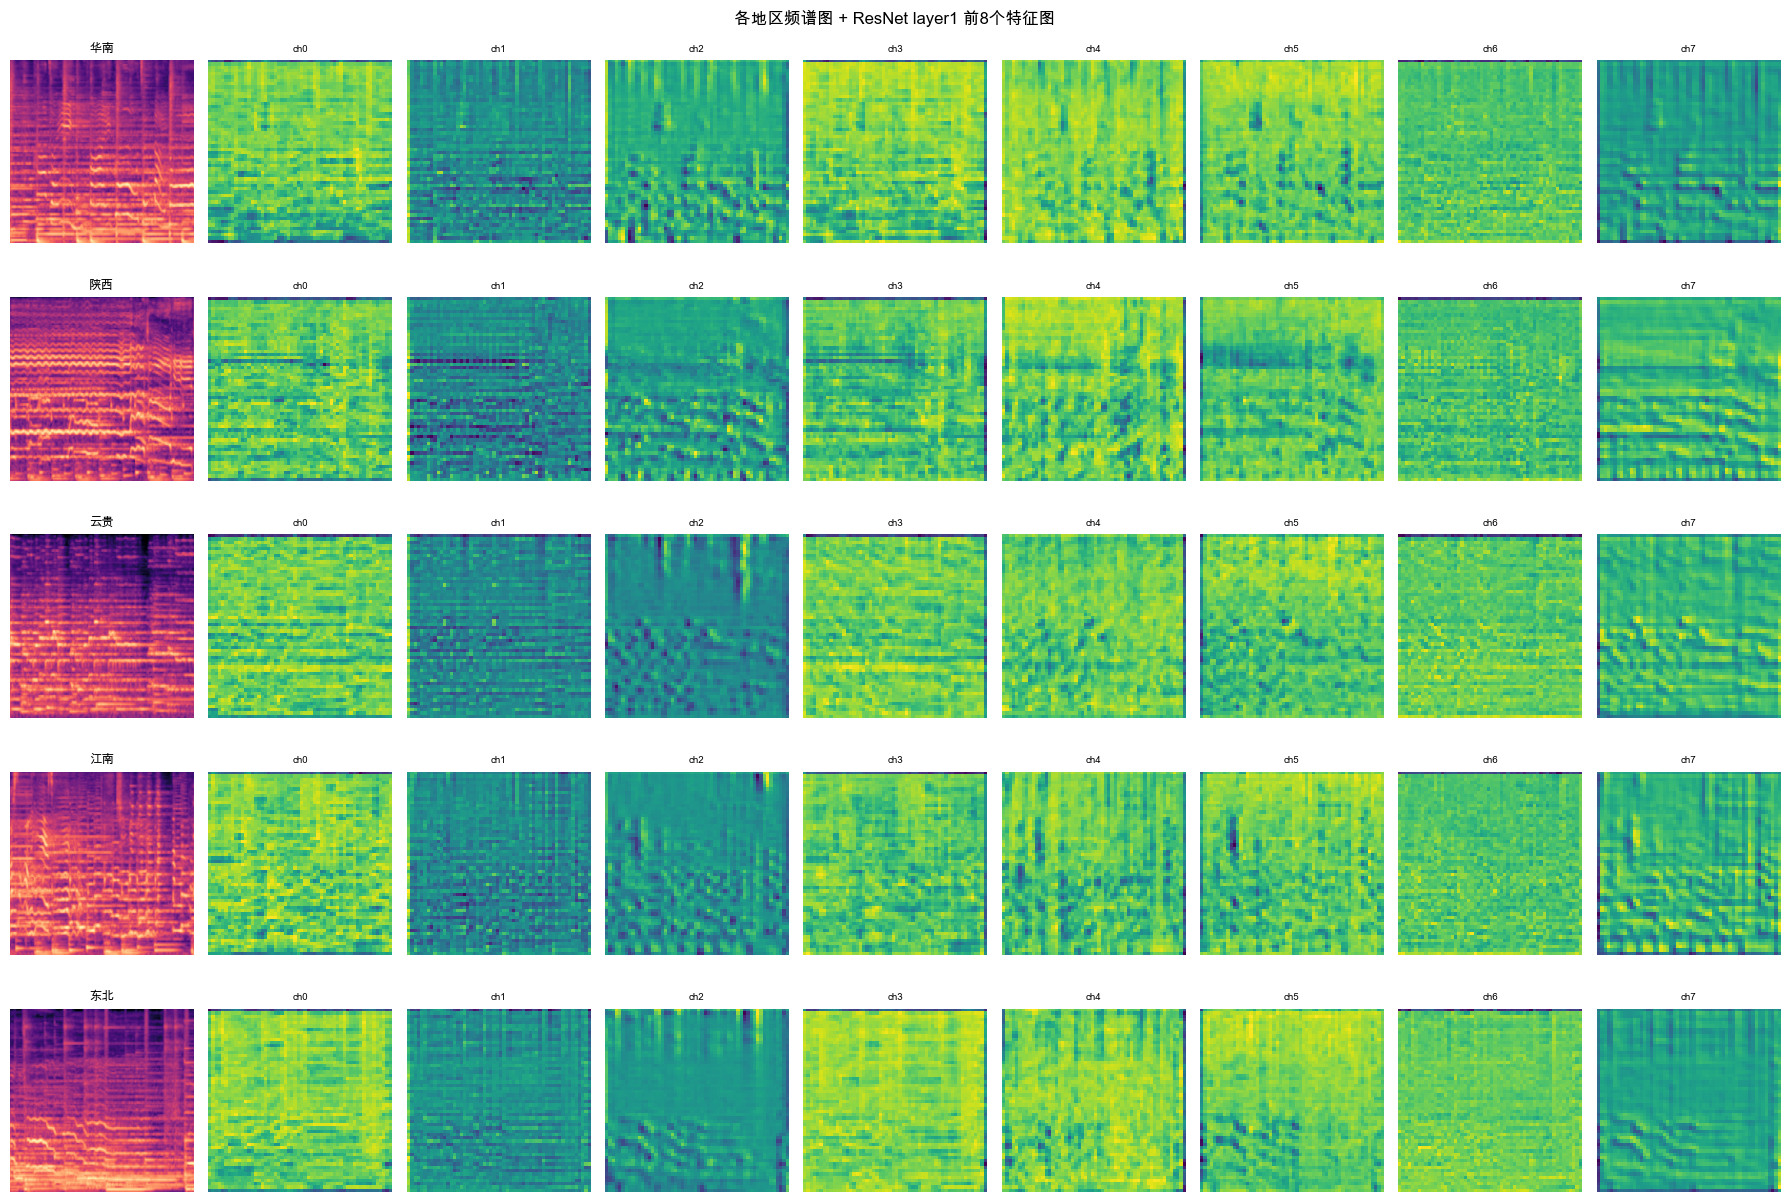

In [7]:
# 从每个类别各取一张做可视化
sample_by_class = {}
for path, label in val_samples:
    cls = IDX_TO_CLASS[label]
    if cls not in sample_by_class:
        sample_by_class[cls] = (path, label)
    if len(sample_by_class) == len(CLASSES): break

feat_maps = {}
def hook_fn(m, i, o): feat_maps['c1'] = o.detach().cpu()
handle = model.layer1[0].conv1.register_forward_hook(hook_fn)

fig, axes = plt.subplots(len(CLASSES), 9, figsize=(18, len(CLASSES)*2.5))
fig.suptitle('各地区频谱图 + ResNet layer1 前8个特征图', fontsize=12)

mn = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
sd = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

for row, cls in enumerate(CLASSES):
    path, label = sample_by_class.get(cls, (None, None))
    if path is None:
        for col in range(9): axes[row][col].axis('off')
        continue
    img_t = val_tf(Image.open(path).convert('RGB'))
    model.eval()
    with torch.no_grad(): model(img_t.unsqueeze(0).to(DEVICE))
    fmaps = feat_maps['c1'][0]
    orig  = (img_t * sd + mn).permute(1,2,0).clamp(0,1).numpy()
    axes[row][0].imshow(orig)
    axes[row][0].set_title(CLASS_ZH[cls], fontsize=9, fontweight='bold')
    for i in range(8):
        axes[row][i+1].imshow(fmaps[i].numpy(), cmap='viridis')
        axes[row][i+1].set_title(f'ch{i}', fontsize=7)
    for col in range(9): axes[row][col].axis('off')

handle.remove()
plt.tight_layout(); plt.show()

## 8. 推理接口（给单个音频片段分类）

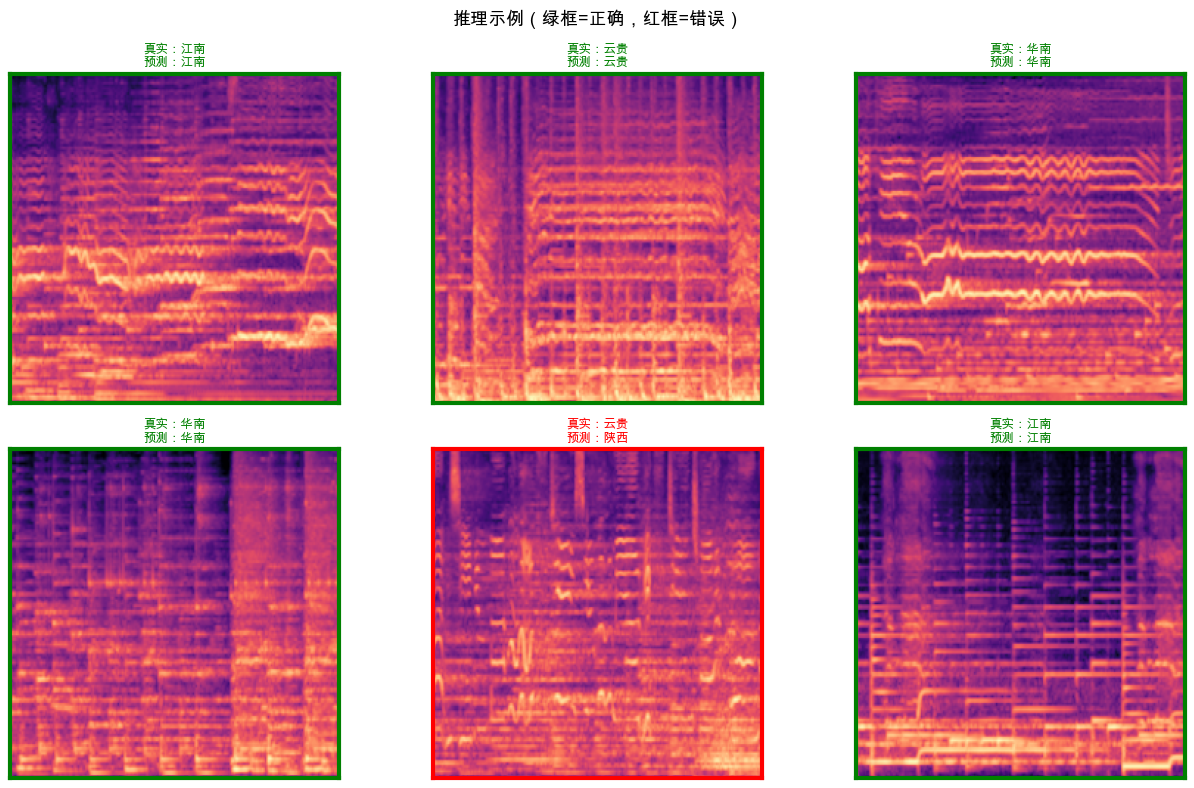


置信度明细（最后一个样本）：
  华南: 8.9%
  陕西: 22.1%
  云贵: 10.6%
  江南: 47.4%
  东北: 11.1%


In [8]:
def predict_image(img_path):
    """输入一张频谱图 PNG，返回预测地区和置信度"""
    img = val_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(img), dim=1)[0].cpu().tolist()
    pred = IDX_TO_CLASS[int(np.argmax(probs))]
    conf = {CLASS_ZH[IDX_TO_CLASS[i]]: f'{p*100:.1f}%' for i, p in enumerate(probs)}
    return CLASS_ZH[pred], conf

# 随机取 6 张验证集图片测试
test_samples = random.sample(val_samples, min(6, len(val_samples)))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('推理示例（绿框=正确，红框=错误）', fontsize=13)

for ax, (path, true_label) in zip(axes.flat, test_samples):
    pred_zh, conf = predict_image(str(path))
    true_zh = CLASS_ZH[IDX_TO_CLASS[true_label]]
    correct = (pred_zh == true_zh)
    ax.imshow(Image.open(path))
    color = 'green' if correct else 'red'
    ax.set_title(f'真实：{true_zh}\n预测：{pred_zh}', fontsize=9, color=color)
    for spine in ax.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

# 打印置信度明细
print('\n置信度明细（最后一个样本）：')
for region, pct in conf.items(): print(f'  {region}: {pct}')